# Color–magnitude diagram of the Pleiades

We use real **Gaia** data for the Pleiades cluster to (1) measure its distance from
parallaxes and (2) build a color–magnitude diagram (CMD) — the H–R diagram of a
cluster. The data is a cached Gaia DR3 query (so this runs offline); the query is in
`notes/`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt, csv
rows = list(csv.DictReader(open("data/real/pleiades_gaia.csv")))
plx = np.array([float(r["parallax"]) for r in rows])
err = np.array([float(r["parallax_error"]) for r in rows])
g   = np.array([float(r["phot_g_mean_mag"]) for r in rows])
bp_rp = np.array([float(r["bp_rp"]) for r in rows])
print(len(rows), "Pleiades members")

1033 Pleiades members


## 1. Distance from parallax — mind the bias

Each star's parallax ϖ gives a distance d = 1000/ϖ (pc, mas). But parallaxes are
**noisy**, and 1/ϖ is nonlinear, so averaging per-star distances is *biased*. The fix:
average the parallaxes (inverse-variance weighted) first, then invert once.

In [2]:
from scripts.cluster import cluster_distance, parallax_to_distance
naive = np.mean(parallax_to_distance(plx))      # biased: mean of 1/parallax
robust = cluster_distance(plx, err)              # average parallax, then invert
print(f"naive  mean of 1/parallax : {naive:.1f} pc")
print(f"robust parallax-first     : {robust:.1f} pc")
print(f"literature (Gaia)         : 136.2 pc")

naive  mean of 1/parallax : 135.7 pc
robust parallax-first     : 135.9 pc
literature (Gaia)         : 136.2 pc


## 2. The color–magnitude diagram

Convert apparent G to **absolute** magnitude using the parallax, and plot against
color BP−RP. A single-age cluster traces a tight **main sequence** — hot blue stars
bright at top-left, cool red dwarfs faint at bottom-right.

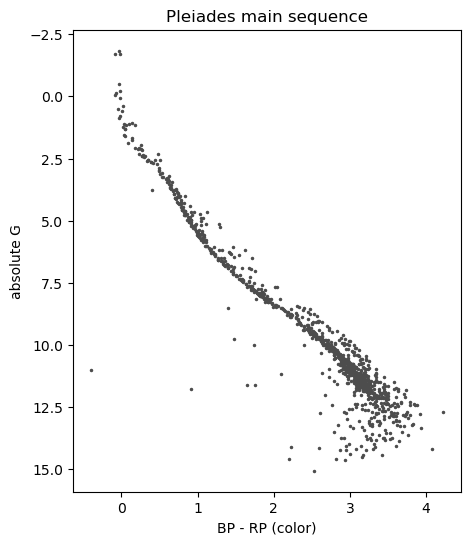

In [3]:
from scripts.cluster import absolute_magnitude
M_G = absolute_magnitude(g, plx)
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(bp_rp, M_G, ".", ms=3, color="0.3"); ax.invert_yaxis()
ax.set_xlabel("BP - RP (color)"); ax.set_ylabel("absolute G")
ax.set_title("Pleiades main sequence"); plt.show()

## 3. Cross-check the conversion

Our parallax→distance must match `astropy.coordinates.Distance` exactly — it's the
standard, unit-aware implementation. (This is the hard check in `tests/test_cluster.py`.)

In [4]:
from astropy.coordinates import Distance
import astropy.units as u
for p in [7.37, 50.0, 100.0]:
    print(f"ϖ={p:6.2f} mas -> ours {parallax_to_distance(p):7.2f} pc, "
          f"astropy {Distance(parallax=p*u.mas).to('pc').value:7.2f} pc")

ϖ=  7.37 mas -> ours  135.69 pc, astropy  135.69 pc
ϖ= 50.00 mas -> ours   20.00 pc, astropy   20.00 pc
ϖ=100.00 mas -> ours   10.00 pc, astropy   10.00 pc


## Result

**Pleiades distance = 135.9 pc** (literature 136.2), from real Gaia parallaxes, and a
clean main-sequence CMD. The headline, testable result is the distance; the CMD is the
visual proof the membership selection is clean. See `notes/HANDOFF_cmd.md`.